In [2]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

import numpy as np 


from scipy.stats import sem

# ImageNet Accuracy

In [3]:
DIR = Path("../../artifacts/2023-08-s10/dev/accuracy-basis-imagenet")

In [4]:
def load(dataset, arch, layer, basis_name, training_size=1.0, logit_mod="oneclass", basis_mode="centered", seeds=[1]):
    
    arr_dfs = []
    for seed in seeds:
#         print(f"training-size={training_size}")
        with open(DIR / f"{dataset}--ts{training_size}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        # todo: also process `xent`
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"],
            }
        )
            
        df["dims"] = data["dims"]

        df["original_acc"] = data["original_acc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df.reset_index()

_df = load(
    dataset="imagenet-butterfly", 
    arch="imagenet-resnet18-tv",
    layer="layer3", 
    basis_name="pca", 
    training_size=0.05
)
_df[20:100]

k       acc      seed original_acc  dims
             mean std count        first first
20   21  0.853333 NaN     1     0.966667   256
21   22  0.860000 NaN     1     0.966667   256
22   23  0.876667 NaN     1     0.966667   256
23   24  0.873333 NaN     1     0.966667   256
24   25  0.880000 NaN     1     0.966667   256
25   26  0.873333 NaN     1     0.966667   256
26   27  0.873333 NaN     1     0.966667   256
27   28  0.883333 NaN     1     0.966667   256
28   29  0.886667 NaN     1     0.966667   256
29   30  0.883333 NaN     1     0.966667   256
30   31  0.886667 NaN     1     0.966667   256
31   32  0.893333 NaN     1     0.966667   256
32   64  0.950000 NaN     1     0.966667   256
33  128  0.950000 NaN     1     0.966667   256
34  256  0.966667 NaN     1     0.966667   256

In [5]:
_df = load(
    dataset="imagenet-butterfly", 
    arch="imagenet-resnet18-tv",
    layer="layer3", 
    basis_name="prca-recon", 
    training_size=0.05
)
_df[20:100]

k       acc      seed original_acc  dims
             mean std count        first first
20   21  0.896667 NaN     1     0.966667   256
21   22  0.903333 NaN     1     0.966667   256
22   23  0.913333 NaN     1     0.966667   256
23   24  0.916667 NaN     1     0.966667   256
24   25  0.913333 NaN     1     0.966667   256
25   26  0.916667 NaN     1     0.966667   256
26   27  0.920000 NaN     1     0.966667   256
27   28  0.920000 NaN     1     0.966667   256
28   29  0.923333 NaN     1     0.966667   256
29   30  0.923333 NaN     1     0.966667   256
30   31  0.923333 NaN     1     0.966667   256
31   32  0.926667 NaN     1     0.966667   256
32   64  0.950000 NaN     1     0.966667   256
33  128  0.950000 NaN     1     0.966667   256
34  256  0.966667 NaN     1     0.966667   256

In [6]:
_df = load(
    dataset="imagenet-butterfly", 
    arch="imagenet-resnet18-tv",
    layer="layer3", 
    basis_name="pcaprca-recon", 
    training_size=0.05
)
_df[20:100]

k       acc      seed original_acc  dims
             mean std count        first first
20   21  0.896667 NaN     1     0.966667   256
21   22  0.896667 NaN     1     0.966667   256
22   23  0.916667 NaN     1     0.966667   256
23   24  0.913333 NaN     1     0.966667   256
24   25  0.913333 NaN     1     0.966667   256
25   26  0.916667 NaN     1     0.966667   256
26   27  0.926667 NaN     1     0.966667   256
27   28  0.926667 NaN     1     0.966667   256
28   29  0.926667 NaN     1     0.966667   256
29   30  0.926667 NaN     1     0.966667   256
30   31  0.930000 NaN     1     0.966667   256
31   32  0.930000 NaN     1     0.966667   256
32   64  0.943333 NaN     1     0.966667   256
33  128  0.950000 NaN     1     0.966667   256
34  256  0.966667 NaN     1     0.966667   256

# Accuracy Basis Curve

## One Class Curve

In [7]:
def color(name):
    if "random" in name:
        return "lightgray"
    elif name in ["rel-abs", "rel-recon", "rel-reconnaive"]  or name in ["act-recon", "act-abs"]:
        return plt.gca().lines[-1].get_color()
    else:
        return None

def marker(name):
    if name in ["pca", "prca-abs", "prca-recon", 'rel-recon', "act-recon"]:
        return "."
    elif "pcaprca" in name:
        return "s"
    elif name in ["rel-reconnaive", "prca-reconnaive"]:
        return "|"
    else:
        return None
    
def ls(name):
    if "rel" in name or "act" in name:
        return "--"
    elif "random" in name:
        return ":"
    else:
        return "-"

## Accuracy Curve Aggregated Over Classes

In [8]:
def basis_displayname(basis_name):
#     mapping = {
#         "random": "Random",
#         "act-recon": "Act",
#         "rel-recon": "Rel",
#         "pca": "PCA",
#         'pcaprca-recon': "PRCA"
#     }
    
    mapping = {}

    return f"{mapping.get(basis_name, basis_name):15s}"


/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: Run

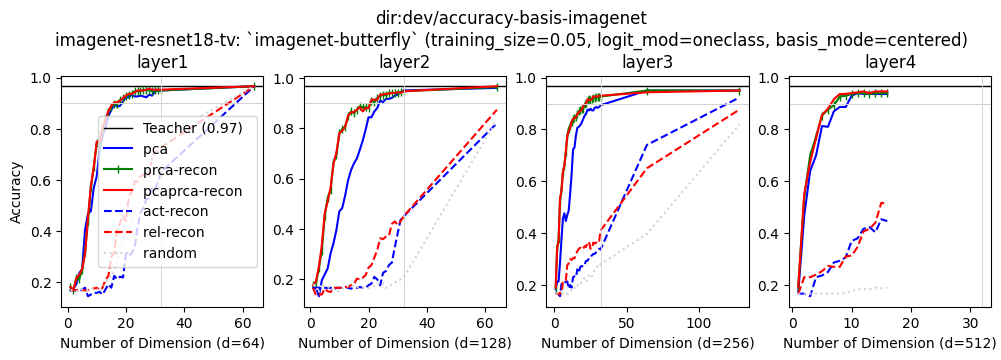

In [20]:
def accuracy_curve(
    arch, layers_and_factors,
    dataset,
    arr_bases = [
        "random",
        "act-recon",
        "rel-recon",
        "pca",
        "pcaprca-recon",
    ],
    logit_mod="oneclass",
    training_size=1.0,
    basis_mode="centered"
):


        
    arr_classes = [dataset]
    ncols = len(layers_and_factors)
    
    plt.figure(figsize=(ncols * 3, 3))
    plt.suptitle("\n".join([
        "dir:" + "/".join(f"{DIR}".split("/")[-2:]),
        f"{arch}: `{dataset}` (training_size={training_size}, logit_mod={logit_mod}, basis_mode={basis_mode})"
    ]), y=1.1)
    
    def color(basis_name):
        if basis_name in ["act-recon", "pca"]:
            return "blue"
        elif basis_name in ["rel-recon", "pcaprca-recon", "rel-raw"]:
            return "red"
        elif "random" == basis_name:
            return "lightgray"
        else:
            return "green"
            raise NotImplementedError(f"no color for `{basis_name}`")
            
    def ls(basis_name):
        if basis_name == "random":
            return ":"
        elif basis_name in ["act-recon", "rel-recon"]:
            return "--"
        else:
            return "-"
    
    def marker(basis_name):
        if basis_name == "prca-recon":
            return "|"
    
    for lix, (layer, factor) in enumerate(layers_and_factors):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)

        teacher_stats = []
        for dataset in arr_classes:
            df = load(
                dataset=dataset,  arch=arch, layer=layer,  basis_name=arr_bases[0],  training_size=training_size,
                logit_mod=logit_mod,
                basis_mode=basis_mode,
            )
            acc = df["original_acc"]["first"].values
            np.testing.assert_equal(acc[0], acc)
            teacher_stats.append(acc[0])
        
        mean_teacher = np.mean(teacher_stats)
        stderr_teacher = sem(teacher_stats)

        assert mean_teacher.shape == stderr_teacher.shape == ()

        plt.axhline(mean_teacher, label=f"Teacher ({mean_teacher:.2f})", color="k", lw=1, ls="-")

        for basis_name in arr_bases:
            stats = []
            for dataset in arr_classes:
                df = load(
                    dataset=dataset, 
                    arch=arch,
                    layer=layer, 
                    basis_name=basis_name, 
                    training_size=training_size,
                    logit_mod=logit_mod,
                    basis_mode=basis_mode
                )
                    
                    
                d = df["dims"]["first"].values[0]
                stats.append(df["acc"]["mean"].values)
                k = df["k"].values
            
            stats = np.array(stats)
            
            selected = k <= d//factor
            
            assert stats.shape == (len(arr_classes), len(k))
            
            mean_stats = np.mean(stats, axis=0)

            _k = k[selected]
            _mean = mean_stats[selected]
            
            plt.axvline(32, ls="-", color="lightgray", lw=0.5)
            plt.axhline(0.9, ls="-", color="lightgray", lw=0.5)

            plt.plot(
                _k,
                _mean, 
                label=basis_displayname(basis_name),
                color=color(basis_name),
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
    
#             stderr_stats = sem(stats, axis=0)
#             assert stderr_stats.shape == mean_stats.shape
#             print(stats.shape)

#                 _stderr = stderr_stats[selected]
# 
#             plt.fill_between(
#                 _k,
#                 _mean - _stderr,
#                 _mean + _stderr,
#                 color=plt.gca().lines[-1].get_color(),
#                 alpha=0.1
#             )
                                
            
            
            
        plt.xlabel(f"Number of Dimension (d={d})")
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()

            
accuracy_curve(
    arch="imagenet-resnet18-tv",
    dataset="imagenet-butterfly",
    training_size=0.05,
    layers_and_factors = [
        ("layer1", 1),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
    arr_bases=[
        "pca", 
        "prca-recon",
        "pcaprca-recon",
        "act-recon",
        "rel-recon",
        "random"
    ]
)

# ImageNet-Butterfly

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: Run

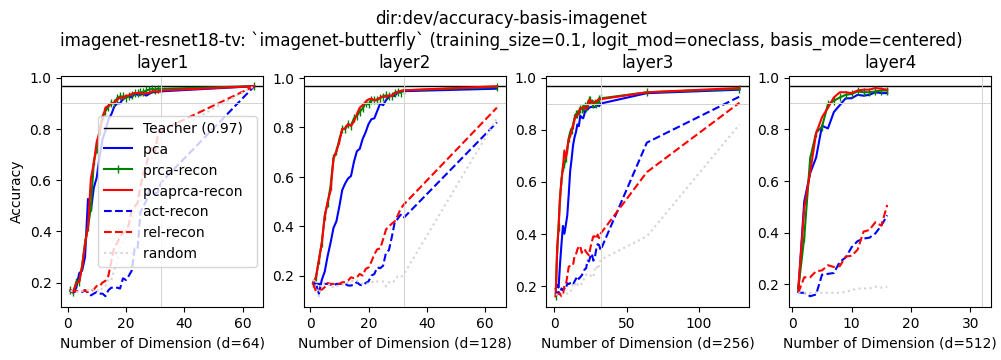

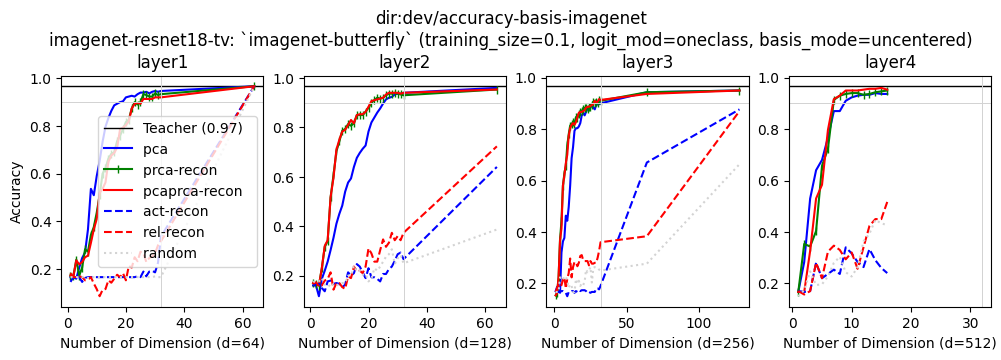

In [21]:
for basis_mode in ["centered", "uncentered"]:
    
    accuracy_curve(
        arch="imagenet-resnet18-tv",
        dataset="imagenet-butterfly",
        training_size=0.1,
        layers_and_factors = [
            ("layer1", 1),
            ("layer2", 2),
            ("layer3", 2),
            ("layer4", 32)
        ],
        arr_bases=[
            "pca", 
            "prca-recon",
            "pcaprca-recon",
            "act-recon",
            "rel-recon",
            "random"
        ],
        basis_mode=basis_mode
    )

In [25]:
512 / 8

64.0

## Comparison of PRCA-abs, PRCA-recon

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: Run

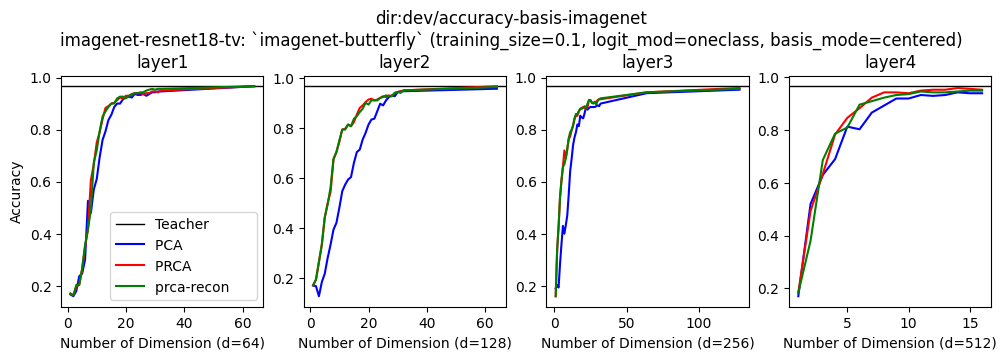

In [130]:
accuracy_curve(
    arch="imagenet-resnet18-tv",
    dataset="imagenet-butterfly",
    training_size=0.1,
    layers_and_factors = [
        ("layer1", 1),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
    arr_bases=[
        "pca", 
        "pcaprca-recon",
        "prca-recon",
    ],
    basis_mode="centered"
)

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: Run

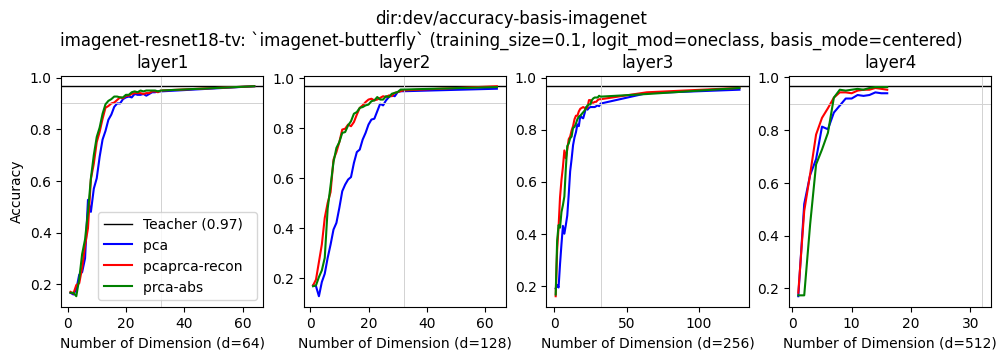

In [24]:
accuracy_curve(
    arch="imagenet-resnet18-tv",
    dataset="imagenet-butterfly",
    training_size=0.1,
    layers_and_factors = [
        ("layer1", 1),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
    arr_bases=[
        "pca", 
        "pcaprca-recon",
        "prca-abs",
    ],
    basis_mode="centered"
)

In [23]:
512 / 8

64.0

## Comparision of Canonical Basis

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: Run

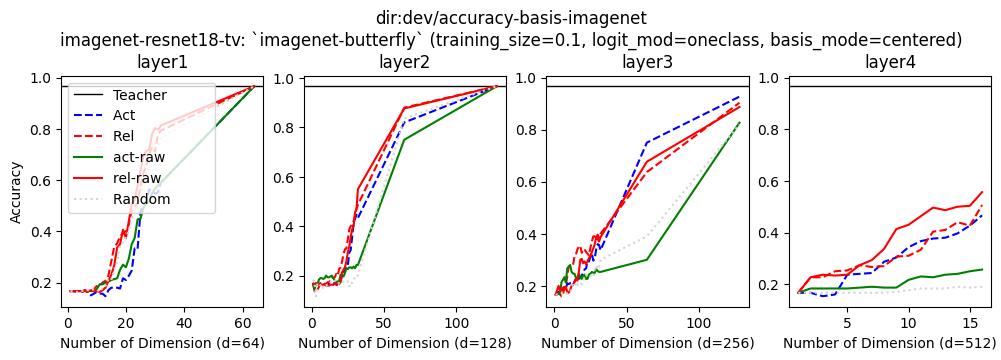

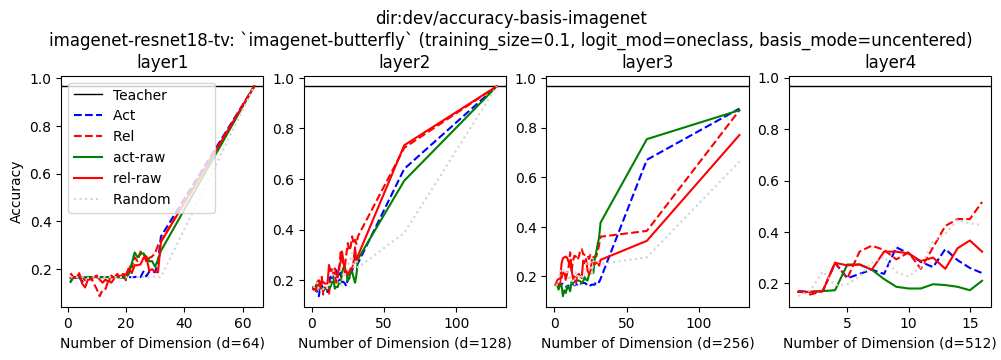

In [128]:
for basis_mode in ["centered", "uncentered"]:
    
    accuracy_curve(
        arch="imagenet-resnet18-tv",
        dataset="imagenet-butterfly",
        training_size=0.1,
        layers_and_factors = [
            ("layer1", 1),
            ("layer2", 1),
            ("layer3", 2),
            ("layer4", 32)
        ],
        basis_mode=basis_mode,
        arr_bases=[
            "act-recon",
            "rel-recon",
            "act-raw",
            "rel-raw",
            "random"
        ]
    )

# ImageNet (all)

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/numpy/core/_methods.py:269: Run

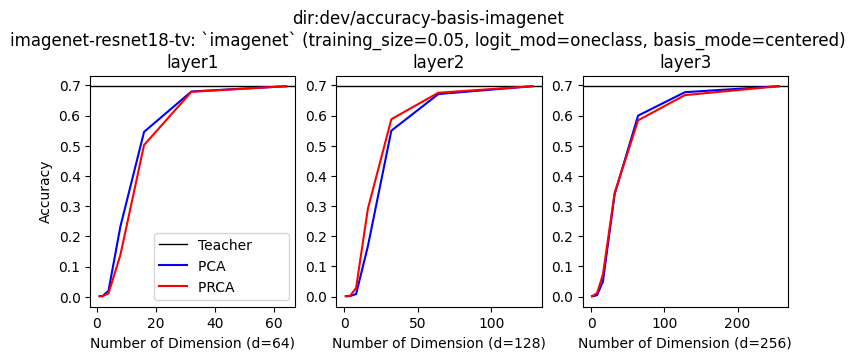

In [125]:
accuracy_curve(
    arch="imagenet-resnet18-tv",
    dataset="imagenet",
    training_size=0.05,
    layers_and_factors = [
        ("layer1", 1),
        ("layer2", 1),
        ("layer3", 1),
#         ("layer4", 32)
    ],
    arr_bases=[
        "pca", 
        "pcaprca-recon",
    ]
)

# Summary


**Aims:** 
1. The notebook compares the quality of PCA and PRCA on the `imagenet-butterly` and `imagenet` using the `imagenet-resnet18-tv` model. 
2. Whether `basis_mode=centered,uncentered` proves better.


**Conclusions**:
1. for `imagenet-butterfly` (`training-size=0.1`), we see that PRCA (`pcaprca-recon`) can recover high accuracy only fewer components than PCA. 
    - But, to reach **the same accuracy of the teacher model**, PRCA and PCA requires approximately **the same number of components**.
2. on `imagenet` (`training-size=0.05`), we do NOT see the beneficial of PRCA.
    - Related factors: number of training samples used to estimate PRCA.


3. (centering or NOT): For PCA and PRCA, we could see that `centering` yields slightly better results, especially for PRCA.
4. (canonical bases): Remark: The canonical bases make more sense with `basis-mode=uncentered`.
    - (uncentered): `rel-recon` seems to be better than `act-recon`, except `layer3`. This is NOT intuitive, and we need to investigate what is happing there. This same obversation also where`act-raw` is BETTER than `rel-raw` at `layer3`.
    - (centered): the above trend is also observed here.